# 03 - Inferência com SAM 2 em imagem e vídeo

Este notebook tem dois caminhos explícitos:

1. **SAM 2 oficial**, usado quando `sam2` e o checkpoint Tiny existem;
2. **baseline de cor**, usado apenas para validar o pipeline sem rede.

O baseline não substitui nem estima o desempenho do SAM 2. A célula de
status informa qual método gerou as métricas e as figuras.

In [1]:
from pathlib import Path


def locate_seminar_dir():
    for candidate in (Path.cwd(), *Path.cwd().parents):
        seminar = candidate if candidate.name == "seminar_2" else candidate / "seminar_2"
        if (seminar / "articles").is_dir():
            return seminar
    raise FileNotFoundError("Execute este notebook dentro do repositório TP558.")


SEMINAR_DIR = locate_seminar_dir()
DATA_DIR = SEMINAR_DIR / "data"
OUTPUT_DIR = DATA_DIR / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(SEMINAR_DIR)

/home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/seminar_2


In [2]:
import csv
import importlib.util

import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image

FRAME_DIR = DATA_DIR / "raw" / "video_demo"
MASK_DIR = DATA_DIR / "processed" / "gt_masks"
CHECKPOINT = DATA_DIR / "models" / "sam2.1_hiera_tiny.pt"
CONFIG = "configs/sam2.1/sam2.1_hiera_t.yaml"

frame_paths = sorted(FRAME_DIR.glob("*.jpg"))
mask_paths = sorted(MASK_DIR.glob("*.png"))
if not frame_paths or len(frame_paths) != len(mask_paths):
    raise FileNotFoundError("Execute primeiro o notebook 02_data_preparation.ipynb.")

frames = [np.asarray(Image.open(path).convert("RGB")) for path in frame_paths]
ground_truth = [np.asarray(Image.open(path)) > 0 for path in mask_paths]
points = np.array([[55, 128], [18, 24]], dtype=np.float32)
labels = np.array([1, 0], dtype=np.int32)

has_package = importlib.util.find_spec("sam2") is not None
SAM2_READY = has_package and CHECKPOINT.exists()
device = "cuda" if torch.cuda.is_available() else "cpu"
print({"sam2_installed": has_package, "checkpoint": CHECKPOINT.exists(), "device": device})

{'sam2_installed': False, 'checkpoint': False, 'device': 'cpu'}


## Segmentação de uma imagem

A API `SAM2ImagePredictor` calcula o embedding da imagem em
`set_image` e pode responder a diferentes prompts sem recodificar a
imagem. Com um clique ambíguo, `multimask_output=True` devolve máscaras
candidatas; selecionamos a de maior IoU prevista.

In [3]:
image_prediction = None
image_score = None

if SAM2_READY:
    from sam2.build_sam import build_sam2
    from sam2.sam2_image_predictor import SAM2ImagePredictor

    image_model = build_sam2(CONFIG, str(CHECKPOINT), device=device)
    image_predictor = SAM2ImagePredictor(image_model)
    with torch.inference_mode():
        image_predictor.set_image(frames[0])
        candidate_masks, candidate_scores, _ = image_predictor.predict(
            point_coords=points,
            point_labels=labels,
            multimask_output=True,
        )
    best = int(np.argmax(candidate_scores))
    image_prediction = candidate_masks[best]
    image_score = float(candidate_scores[best])
    print(f"SAM 2 imagem: IoU prevista={image_score:.3f}")
else:
    print("SAM 2 indisponível; consulte a instalação no README. A célula foi ignorada.")

SAM 2 indisponível; consulte a instalação no README. A célula foi ignorada.


## Propagação no vídeo

O predictor recebe os dois pontos no frame 0, cria o estado de
inferência e propaga o objeto. O estado representa a memória temporal
descrita na Seção 4 do paper.

In [4]:
sam2_predictions = None

if SAM2_READY:
    from sam2.build_sam import build_sam2_video_predictor

    video_predictor = build_sam2_video_predictor(CONFIG, str(CHECKPOINT), device=device)
    state = video_predictor.init_state(video_path=str(FRAME_DIR))
    predictions = {}
    with torch.inference_mode():
        video_predictor.add_new_points_or_box(
            inference_state=state,
            frame_idx=0,
            obj_id=1,
            points=points,
            labels=labels,
        )
        for frame_index, object_ids, mask_logits in video_predictor.propagate_in_video(state):
            object_position = list(object_ids).index(1)
            predictions[frame_index] = (mask_logits[object_position, 0] > 0).cpu().numpy()
    sam2_predictions = [predictions[index] for index in range(len(frames))]
    print(f"SAM 2 propagou {len(sam2_predictions)} máscaras.")
else:
    print("Propagação SAM 2 ignorada: pacote ou checkpoint ausente.")

Propagação SAM 2 ignorada: pacote ou checkpoint ausente.


## Baseline didático e escolha explícita do resultado

Como o objeto sintético é azul, um limiar nos canais RGB o separa. Esse
baseline testa leitura, escrita, visualização e métricas mesmo em uma
máquina sem checkpoint. Ele não possui prompts nem memória e falharia
quando alvo e fundo tivessem cores semelhantes.

In [5]:
def color_baseline(frame):
    red, green, blue = np.moveaxis(frame.astype(np.int16), -1, 0)
    return (blue > red + 45) & (blue > green + 45)


baseline_predictions = [color_baseline(frame) for frame in frames]
method = "SAM 2 Tiny" if sam2_predictions is not None else "baseline de cor (não SAM 2)"
video_predictions = sam2_predictions or baseline_predictions


def iou(mask_a, mask_b):
    intersection = np.logical_and(mask_a, mask_b).sum()
    union = np.logical_or(mask_a, mask_b).sum()
    return intersection / union if union else 1.0


ious = np.array([iou(pred, target) for pred, target in zip(video_predictions, ground_truth, strict=True)])
assert np.all((0 <= ious) & (ious <= 1))
print(f"Método avaliado: {method}")
print(f"IoU médio: {ious.mean():.3f}; mínimo: {ious.min():.3f}")

Método avaliado: baseline de cor (não SAM 2)
IoU médio: 0.994; mínimo: 0.973


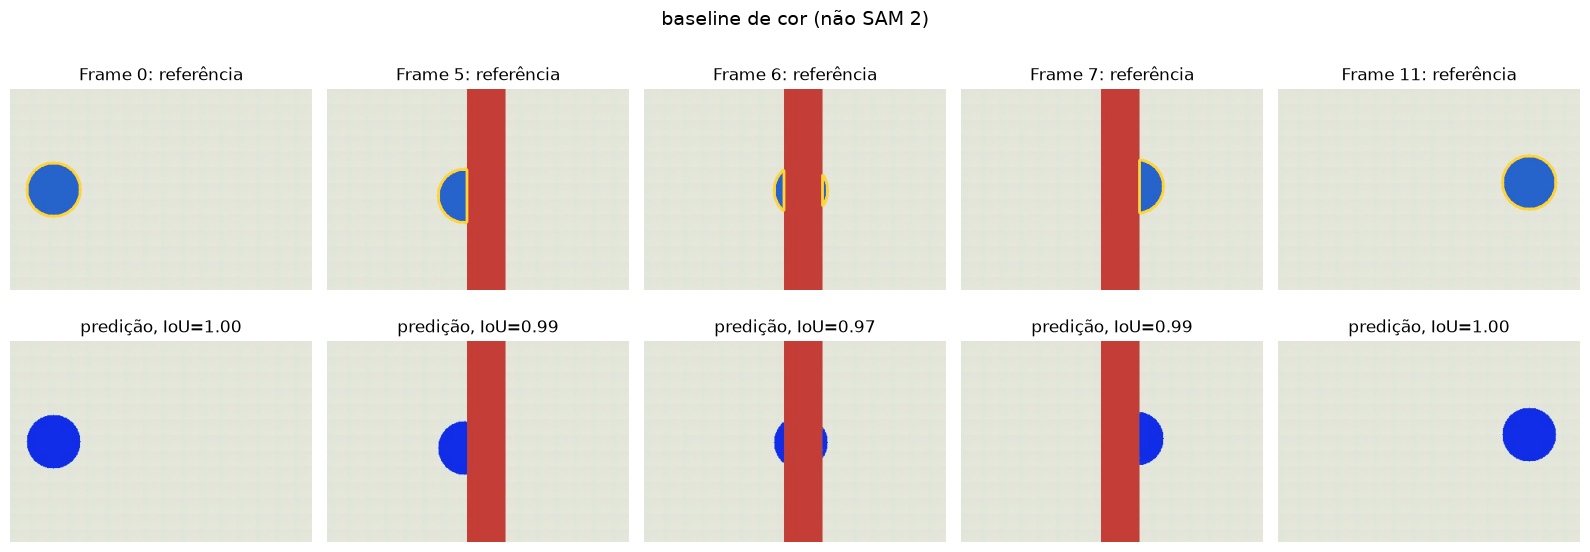

In [6]:
metrics_path = OUTPUT_DIR / "demo_iou_by_frame.csv"
with metrics_path.open("w", newline="", encoding="utf-8") as stream:
    writer = csv.writer(stream)
    writer.writerow(["method", "frame", "iou"])
    writer.writerows((method, index, score) for index, score in enumerate(ious))

prediction_dir = OUTPUT_DIR / ("sam2_masks" if sam2_predictions is not None else "baseline_masks")
prediction_dir.mkdir(exist_ok=True)
for index, prediction in enumerate(video_predictions):
    Image.fromarray((prediction * 255).astype(np.uint8)).save(prediction_dir / f"{index:05d}.png")

selected = [0, 5, 6, 7, 11]
fig, axes = plt.subplots(2, len(selected), figsize=(16, 6))
for column, index in enumerate(selected):
    axes[0, column].imshow(frames[index])
    axes[0, column].contour(ground_truth[index], [0.5], colors=["#ffd43b"], linewidths=2)
    axes[0, column].set_title(f"Frame {index}: referência")
    axes[1, column].imshow(frames[index])
    axes[1, column].imshow(np.ma.masked_where(~video_predictions[index], video_predictions[index]),
                           cmap="winter", alpha=0.55)
    axes[1, column].set_title(f"predição, IoU={ious[index]:.2f}")
    axes[0, column].axis("off")
    axes[1, column].axis("off")
fig.suptitle(method, fontsize=14)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "demo_segmentation_strip.png", dpi=180, bbox_inches="tight")
plt.show()

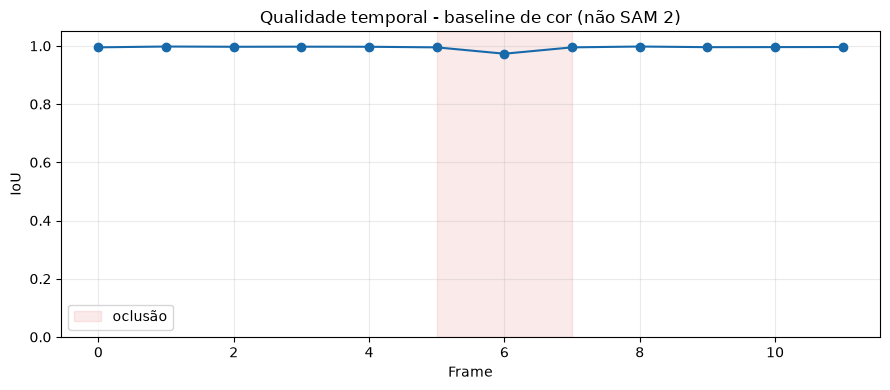

In [7]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(len(ious)), ious, marker="o", color="#1769aa")
ax.axvspan(5, 7, color="#d9534f", alpha=0.12, label="oclusão")
ax.set(xlabel="Frame", ylabel="IoU", ylim=(0, 1.05), title=f"Qualidade temporal - {method}")
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "demo_iou_curve.png", dpi=180, bbox_inches="tight")
plt.show()

## Como interpretar

Em uma execução com SAM 2, observe especialmente os frames 5--7: a
memória deve manter a identidade durante a oclusão e recuperar o alvo
no reaparecimento. Uma correção interativa pode ser adicionada com
`add_new_points_or_box` no frame de maior erro, reproduzindo o ciclo da
Figura 2 do paper.